# Week 2 Data Exploration

Tasks:
- Load minimum 6 months of dataset into pandas
- Explore Distributions of:
	1. ClosePrice (target variable)
	2. LivingArea 
	3. Bedrooms
	4. Bathrooms
	5. LotSize
- . Restrict Analysis to PropertyType = Residential and SingleFamilyResidence (per task doc)

# Task 1: Load dataset into pandas
(I did it programmatically instead of inserting every individual set by hand.)

It would be helpful to put them all together too

In [3]:
import pandas as pd
from pathlib import Path
# the root directory of project
root = "C:/Users/donutii/Desktop/IDX-Exchange-Internship-Data-Science-61"

# Fetch houses sold in between May 2025 and May 2026
houses_sold_by_month = []

for month in range(0, 12):
    y = "2025" if month < 8 else "2026"
    m =  ""
    if (month + 5 < 10):
        m = f"0{5 + month}"
    elif (month + 5 >= 10 and month + 5 < 13): 
       m = f"{5 + month}" 
    else:
        m = f"0{month - 7}"
    # print(f"../raw_data/CRMLSSold{y}{m}.csv")-Science-61\raw_data\california\CRMLSSold202506.csv
    filename = f"{root}/raw_data/california/CRMLSSold{y}{m}.csv"
    houses_sold_by_month.append(pd.read_csv(filename))

# Concatenate dataframes
# Ignoring indexes because I'm sure there are duplicates somewhere in the data
houses_sold_2026 = pd.concat(houses_sold_by_month, ignore_index=True)

C:\Users\donutii\AppData\Local\Temp\ipykernel_13060\3932654870.py:20: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  houses_sold_by_month.append(pd.read_csv(filename))
C:\Users\donutii\AppData\Local\Temp\ipykernel_13060\3932654870.py:20: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  houses_sold_by_month.append(pd.read_csv(filename))


In [4]:
# Restricting rows to ones that are Residential and single family (as per task instructions)
# Using this tutorial: https://www.geeksforgeeks.org/python/selecting-rows-in-pandas-dataframe-based-on-conditions/
residential = houses_sold_2026[houses_sold_2026['PropertyType'].isin(['Residential'])]
residential_single_family = residential[residential['PropertySubType'].isin(['SingleFamilyResidence'])]

# Task 2: Explore Distributions
For more explanation on EDAs, it might be helpful to look here: https://www.geeksforgeeks.org/data-analysis/what-is-exploratory-data-analysis/ 

We specifically want to explore the distributions of:
- ClosePrice (the target variable)
- LivingArea
- Bedrooms
- Bathrooms
- LotSize


In [19]:
# Importing matplotlib 
import matplotlib.pyplot as plt

# Functions
def show_histogram(data, bins, log, color, title, xlabel):
    plt.hist(data, bins=bins, log=log, color=color, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')

    plt.show()


## Exploring Distribution of ClosePrice
I will be using a histogram and box plot to visualize distribution and outliers.

In [54]:
# Checking and cleaning data
print(residential_single_family['ClosePrice'].max())
print(residential_single_family['ClosePrice'][residential_single_family['ClosePrice'] > 0])

trimmed_price = residential_single_family['ClosePrice'].dropna()

989500000.0
8         1800000.0
9         1200000.0
12        2250000.0
13        1425000.0
14         660000.0
            ...    
258529     725000.0
258530     405000.0
258531     215000.0
258533     415000.0
258536    1355000.0
Name: ClosePrice, Length: 129972, dtype: float64


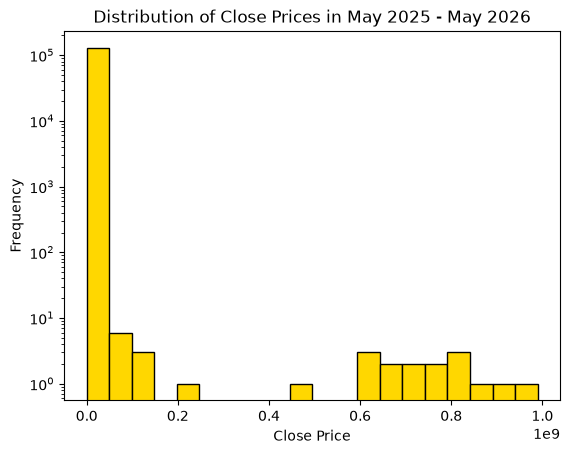

In [55]:
# Distribution of ClosePrice
# print(residential_single_family['ClosePrice'])
show_histogram(trimmed_price, bins=20, log=True, color='gold', title='Distribution of Close Prices in May 2025 - May 2026', xlabel='Close Price')

